In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from contextlib import contextmanager
from PIL import Image
from skimage import measure

In [12]:
aperture_shape = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\Demo\\Gigi\\Assets\\NoiseTextures\\UniformStar\\UniformStar.png"

In [13]:
aperture_texture = None
aperture_texture_shape = None
APERTURE_OPEN_THRESHOLD = 0.5
APERTURE_TEXTURE_RADIUS_MM = None
TEXTURED_APERTURE_INDICES = set()

def load_aperture_texture():
    global aperture_texture, aperture_texture_shape
    if aperture_texture is None:
        image = Image.open(aperture_shape).convert("L")
        aperture_texture = np.asarray(image, dtype=np.float32) / 255.0
        aperture_texture_shape = aperture_texture.shape
    return aperture_texture, aperture_texture_shape

In [14]:
N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
APERTURE_F_STOPS = np.array([2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0])
APERTURE_DIAMETERS_MM = np.array([3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0])
APERTURE_INDEX = len(APERTURE_DIAMETERS_MM) - 1  # widest setting for fully open aperture
APERTURE_RADIUS = 0.5 * APERTURE_DIAMETERS_MM[APERTURE_INDEX] * ratio

radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
LENS = list(zip(
    [curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
) )
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)
TEXTURED_APERTURE_INDICES = {
    6
}
APERTURE_CHECK_ENABLED = [False] * len(LENS)

def set_aperture_check(element_index, enabled):
    APERTURE_CHECK_ENABLED[element_index] = bool(enabled)

def toggle_aperture_check(element_index):
    APERTURE_CHECK_ENABLED[element_index] = not APERTURE_CHECK_ENABLED[element_index]
    return APERTURE_CHECK_ENABLED[element_index]

def compute_lens_surfaces(lens=LENS):
    z_cursor = 0.0
    surfaces = []
    media_before = []
    media_after = []
    medium_before = N_AIR
    for curvature, thickness, n_next, aperture in lens:
        surfaces.append(z_cursor)
        media_before.append(medium_before)
        media_after.append(n_next)
        medium_before = n_next
        z_cursor += thickness
    return (
        np.asarray(surfaces, dtype=float),
        np.asarray(media_before, dtype=float),
        np.asarray(media_after, dtype=float),
    )

LENS_SURFACE_Z, LENS_MEDIA_BEFORE, LENS_MEDIA_AFTER = compute_lens_surfaces()

APERTURE_ELEMENT_INDEX = 5
t_focus_distance = 45.0
SENSOR_PLANE_OFFSET_MM = 335.598 / (t_focus_distance + 15.4) + 37.887
SENSOR_PLANE_POSITION_MM = LENS_SURFACE_Z[-1] + SENSOR_PLANE_OFFSET_MM
Z_ORIGIN_SHIFT_MM = SENSOR_PLANE_POSITION_MM
SENSOR_PLANE_Z_MM = 0.0
LENS_SURFACE_Z = LENS_SURFACE_Z - Z_ORIGIN_SHIFT_MM
APERTURE_Z_MM = LENS_SURFACE_Z[APERTURE_ELEMENT_INDEX]
RAY_EXTENSION_MM = 60.0

def aperture_allows(hit_point, aperture_radius, element_index=None):
    if aperture_radius <= 0.0:
        return True
    x, y = hit_point[0], hit_point[1]
    if element_index is not None and not APERTURE_CHECK_ENABLED[element_index]:
        return True
    if x * x + y * y > aperture_radius * aperture_radius:
        return False
    # Only elements flagged in TEXTURED_APERTURE_INDICES use the texture mask.
    if element_index is None or element_index not in TEXTURED_APERTURE_INDICES:
        return True
    texture, shape = load_aperture_texture()
    if texture is None or shape is None:
        return False
    height, width = shape
    u = 0.5 + 0.5 * (x / aperture_radius)
    v = 0.5 - 0.5 * (y / aperture_radius)
    if u < 0.0 or u > 1.0 or v < 0.0 or v > 1.0:
        return False
    x_idx = int(round(u * (width - 1)))
    y_idx = int(round(v * (height - 1)))
    return texture[y_idx, x_idx] <= APERTURE_OPEN_THRESHOLD

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal


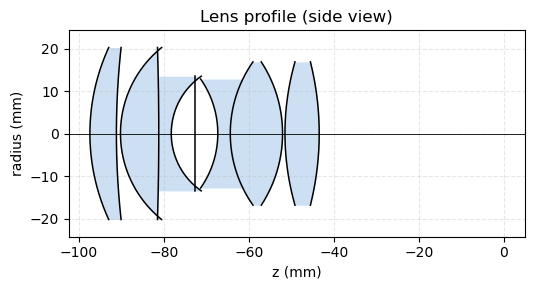

In [15]:
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)


def spherical_profile(curvature, z_surface, aperture, samples=240):
    if aperture <= 0.0:
        return None
    r = np.linspace(-aperture, aperture, samples)
    if abs(curvature) < 1e-9:
        z = np.full_like(r, z_surface, dtype=float)
    else:
        radius = abs(curvature)
        z_center = z_surface + curvature
        sag = np.sqrt(np.clip(radius * radius - r * r, 0.0, None))
        z = z_center - np.sign(curvature) * sag
    return z, r


def add_lens_profile(ax, lens=LENS, *, samples=240, glass_color="#71a7dd", glass_alpha=0.35, z_offset=0.0):
    surfaces = []
    z_surface = LENS_SURFACE_Z[0]
    for curvature, thickness, n_next, aperture in lens:
        profile = spherical_profile(curvature, z_surface, aperture, samples=samples)
        surfaces.append((curvature, z_surface, aperture, n_next))
        if profile is not None:
            z_vals, r_vals = profile
            ax.plot(z_vals - z_offset, r_vals, color="black", linewidth=1.1)
        z_surface += thickness

    for idx in range(len(surfaces) - 1):
        curvature_a, z_a, aperture_a, n_medium = surfaces[idx]
        curvature_b, z_b, aperture_b, _ = surfaces[idx + 1]
        if n_medium <= N_AIR + 1e-6:
            continue
        aperture_fill = min(aperture_a, aperture_b)
        if aperture_fill <= 0.0:
            continue
        profile_a = spherical_profile(curvature_a, z_a, aperture_fill, samples=samples)
        profile_b = spherical_profile(curvature_b, z_b, aperture_fill, samples=samples)
        if profile_a is None or profile_b is None:
            continue
        z_left, r_vals = profile_a
        z_right, _ = profile_b
        z_min = np.minimum(z_left, z_right) - z_offset
        z_max = np.maximum(z_left, z_right) - z_offset
        ax.fill_betweenx(r_vals, z_min, z_max, color=glass_color, alpha=glass_alpha, linewidth=0.0)
    surfaces_offset = [(curvature, z - z_offset, aperture, n_next) for curvature, z, aperture, n_next in surfaces]
    return surfaces_offset


 # Example usage: create a figure, call the helper, and format the plot outside the function.
fig, ax = plt.subplots(figsize=(8.0, 3.0))
add_lens_profile(ax)
ax.axhline(0.0, color="black", linewidth=0.6)
ax.set_title("Lens profile (side view)")
ax.set_xlabel("z (mm)")
ax.set_ylabel("radius (mm)")
ax.set_xlim(LENS_SURFACE_Z[0] - 5.0, 5.0)
ax.set_ylim(-APERTURE_RADIUS * 1.8, APERTURE_RADIUS * 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Precomputed surfaces and media are available via compute_lens_surfaces().
def trace_ray_verbose_reverse(ray_origin, target_point):
    """Traced from film plane to scene."""
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy(),
            "failure_index": -1
        }
    direction /= norm_dir
    n_current = LENS_MEDIA_AFTER[-1]
    for idx in range(len(LENS) - 1, -1, -1):
        z_surface = LENS_SURFACE_Z[idx]
        curvature, thickness, n_next, aperture = LENS[idx]
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy(),
                "failure_index": idx
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, idx):
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        n_target = LENS_MEDIA_BEFORE[idx]
        if n_target <= 0.0:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "invalid_medium",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        eta = n_current / n_target
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy(),
                "failure_index": idx
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_target
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None,
        "failure_index": None
    }

In [17]:
sony_sensor_width = 35.9
sony_sensor_height = 24.0
aspect = 3 / 2
sensor_height = min(sony_sensor_height, sony_sensor_width / aspect)
sensor_width  = sensor_height * aspect

SENSOR_WIDTH_MM = sensor_width
SENSOR_HEIGHT_MM = sensor_height

In [29]:
def trace_loss_to_aperture(ray_origin, target_point, aperture_index=APERTURE_ELEMENT_INDEX):
    """Return how far a ray misses the aperture center when traced from film to the aperture element."""
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "loss": np.inf,
            "hit": origin.copy(),
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_index": -1,
        }
    direction /= norm_dir
    n_current = LENS_MEDIA_AFTER[-1]
    for idx in range(len(LENS) - 1, aperture_index - 1, -1):
        z_surface = LENS_SURFACE_Z[idx]
        curvature, thickness, n_next, aperture = LENS[idx]
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "loss": np.inf,
                "hit": path[-1].copy(),
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_index": idx,
            }
        hit, normal = result
        path.append(hit.copy())
        if idx == aperture_index:
            loss = np.linalg.norm(hit[:2])
            return {
                "loss": loss,
                "hit": hit,
                "path": np.vstack(path),
                "failure": None,
                "failure_index": None,
            }
        n_target = LENS_MEDIA_BEFORE[idx]
        if n_target <= 0.0:
            return {
                "loss": np.inf,
                "hit": hit.copy(),
                "path": np.vstack(path),
                "failure": "invalid_medium",
                "failure_index": idx,
            }
        eta = n_current / n_target
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "loss": np.inf,
                "hit": hit.copy(),
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_index": idx,
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_target
    return {
        "loss": np.inf,
        "hit": path[-1].copy(),
        "path": np.vstack(path),
        "failure": "aperture_not_reached",
        "failure_index": aperture_index,
    }


def find_direction_to_aperture_center(
    film_point, *, aperture_index=APERTURE_ELEMENT_INDEX, tol_loss=1e-4, tol_step=1e-4, max_iters=100, initial_step=None
):
    """Iteratively aim from a film point so the ray hits the aperture center."""
    film_point = np.array(film_point, dtype=float)
    base_center = np.array([0.0, 0.0, LENS_SURFACE_Z[-1]], dtype=float)
    base_radius = abs(LENS[-1][3])
    step = (initial_step if initial_step is not None else (0.5 * base_radius if base_radius > 0.0 else 0.5 * APERTURE_RADIUS))
    best_target = base_center.copy()
    best_result = trace_loss_to_aperture(film_point, best_target, aperture_index=aperture_index)
    evaluations = 1
    for _ in range(max_iters):
        if best_result["loss"] <= tol_loss and step <= tol_step:
            break
        offsets = (step, -step)
        candidates = [best_target + np.array([dx, dy, 0.0]) for dx in offsets for dy in offsets]
        improved = False
        for candidate in candidates:
            trial = trace_loss_to_aperture(film_point, candidate, aperture_index=aperture_index)
            evaluations += 1
            if trial["loss"] < best_result["loss"]:
                best_result = trial
                best_target = candidate
                improved = True
        step *= 0.75
        if not improved and step <= tol_step:
            break
    direction = best_target - film_point
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "direction": None,
            "loss": best_result["loss"],
            "aperture_hit": best_result.get("hit"),
            "target_point": best_target,
            "evaluations": evaluations,
            "failure": "degenerate_direction",
            "best_path": best_result.get("path"),
        }
    direction /= norm_dir
    return {
        "direction": direction,
        "loss": best_result["loss"],
        "aperture_hit": best_result.get("hit"),
        "target_point": best_target,
        "evaluations": evaluations,
        "failure": best_result.get("failure"),
        "best_path": best_result.get("path"),
        "final_step": step,
    }


def plot_ray_solution(
    film_point, *, figsize=(9.5, 4.0), tol_loss=1e-4, tol_step=1e-4, max_iters=32, extension_mm=None
):
    """Solve for the aperture-centered ray from a film point and plot it through the lens."""
    solution = find_direction_to_aperture_center(
        film_point, aperture_index=APERTURE_ELEMENT_INDEX, tol_loss=tol_loss, tol_step=tol_step, max_iters=max_iters
    )
    if solution["failure"] is not None:
        raise ValueError(f"Ray search failed: {solution['failure']}")
    if solution["direction"] is None:
        raise ValueError("No valid direction returned.")
    travel = extension_mm if extension_mm is not None else (abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION_MM)
    target_far = film_point + solution["direction"] * travel
    full_trace = trace_ray_verbose_reverse(film_point, target_far)
    if full_trace["failure"] is not None:
        raise ValueError(f"Full trace failed: {full_trace['failure']}")
    path = full_trace["path"]
    r_vals = np.linalg.norm(path[:, :2], axis=1)
    fig, ax = plt.subplots(figsize=figsize)
    add_lens_profile(ax)
    ax.plot(path[:, 2], r_vals, color="crimson", linewidth=1.6, label="ray path")
    ax.scatter([APERTURE_Z_MM], [0.0], color="black", s=24, label="aperture center")
    if solution.get("aperture_hit") is not None:
        ax.scatter(
            [solution["aperture_hit"][2]],
            [np.linalg.norm(solution["aperture_hit"][:2])],
            color="orange",
            s=28,
            label="aperture hit",
            zorder=5,
        )
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("radius (mm)")
    ax.set_title("Ray traced from film through lens")
    ax.axhline(0.0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    return solution, full_trace, ax

Center loss: 0.0 evaluations: 129
Off-axis loss: 0.0008876036731573495 evaluations: 129


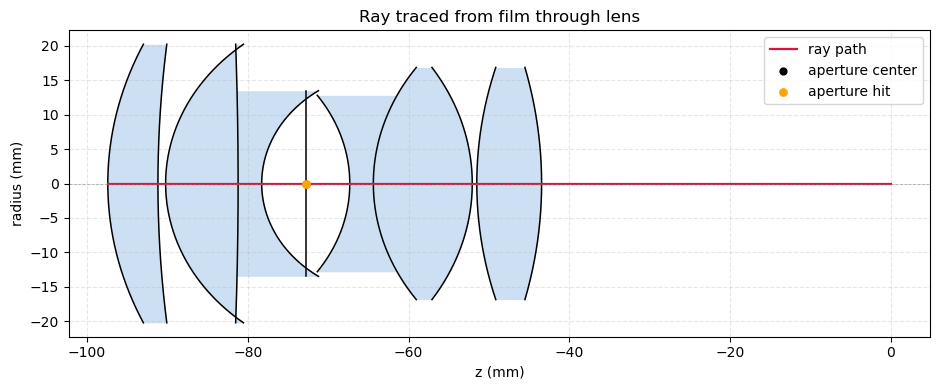

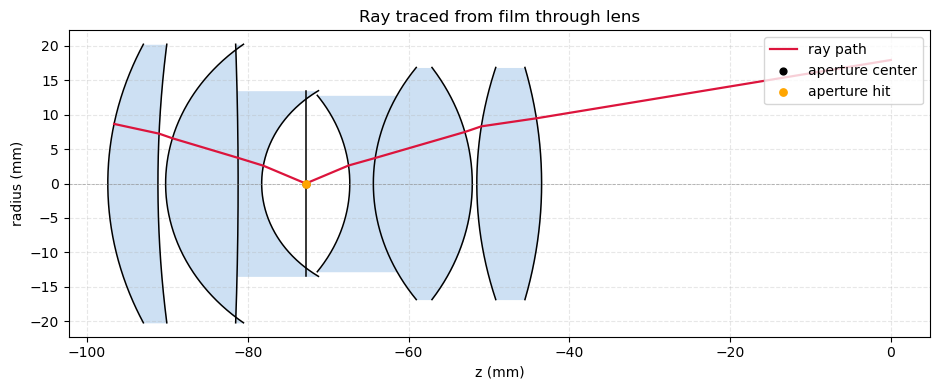

In [30]:
# Example usages: center and off-axis film points
film_center = np.array([0.0, 0.0, SENSOR_PLANE_Z_MM])
film_off_axis = np.array([0.5 * SENSOR_WIDTH_MM, 0.0, SENSOR_PLANE_Z_MM])
center_solution, center_full, center_ax = plot_ray_solution(film_center)
off_solution, off_full, off_ax = plot_ray_solution(film_off_axis)
print("Center loss:", center_solution["loss"], "evaluations:", center_solution["evaluations"])
print("Off-axis loss:", off_solution["loss"], "evaluations:", off_solution["evaluations"])

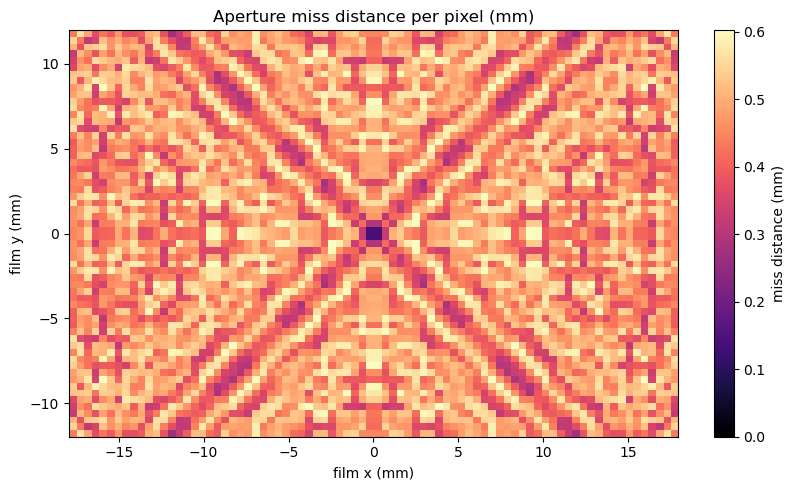

In [31]:
# Compute aperture-centered ray for every pixel on an 800x600 sensor grid and plot loss heatmap
def solve_sensor_grid(width_px=80, height_px=60, *, stride=1, tol_loss=1e-5, tol_step=1e-5, max_iters=10):
    pixel_pitch_x = SENSOR_WIDTH_MM / width_px
    pixel_pitch_y = SENSOR_HEIGHT_MM / height_px
    x0 = -0.5 * SENSOR_WIDTH_MM + 0.5 * pixel_pitch_x
    y0 = -0.5 * SENSOR_HEIGHT_MM + 0.5 * pixel_pitch_y
    losses = np.full((height_px, width_px), np.nan, dtype=float)
    failures = np.zeros((height_px, width_px), dtype=bool)
    for j in range(0, height_px, stride):
        y = y0 + j * pixel_pitch_y
        for i in range(0, width_px, stride):
            x = x0 + i * pixel_pitch_x
            film_pt = np.array([x, y, SENSOR_PLANE_Z_MM], dtype=float)
            try:
                sol = find_direction_to_aperture_center(film_pt, tol_loss=tol_loss, tol_step=tol_step, max_iters=max_iters)
                losses[j, i] = sol["loss"]
                failures[j, i] = sol["failure"] is not None or sol["direction"] is None
            except Exception:
                failures[j, i] = True
    return losses, failures, pixel_pitch_x, pixel_pitch_y
loss_map, failure_map, dx_mm, dy_mm = solve_sensor_grid()
fig, ax = plt.subplots(figsize=(9.5, 5.0))
extent = [ -0.5 * SENSOR_WIDTH_MM, 0.5 * SENSOR_WIDTH_MM, -0.5 * SENSOR_HEIGHT_MM, 0.5 * SENSOR_HEIGHT_MM ]
im = ax.imshow(loss_map, origin="lower", extent=extent, cmap="magma", vmin=0.0, vmax=np.nanpercentile(loss_map, 99))
ax.set_xlabel("film x (mm)")
ax.set_ylabel("film y (mm)")
ax.set_title("Aperture miss distance per pixel (mm)")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("miss distance (mm)")
if failure_map.any():
    ax.contour(failure_map.astype(float), levels=[0.5], colors="cyan", linestyles="--", linewidths=0.8, origin="lower", extent=extent, label="failures")
plt.tight_layout()
plt.show()

Plotted 300 rays; skipped 0 due to failures.


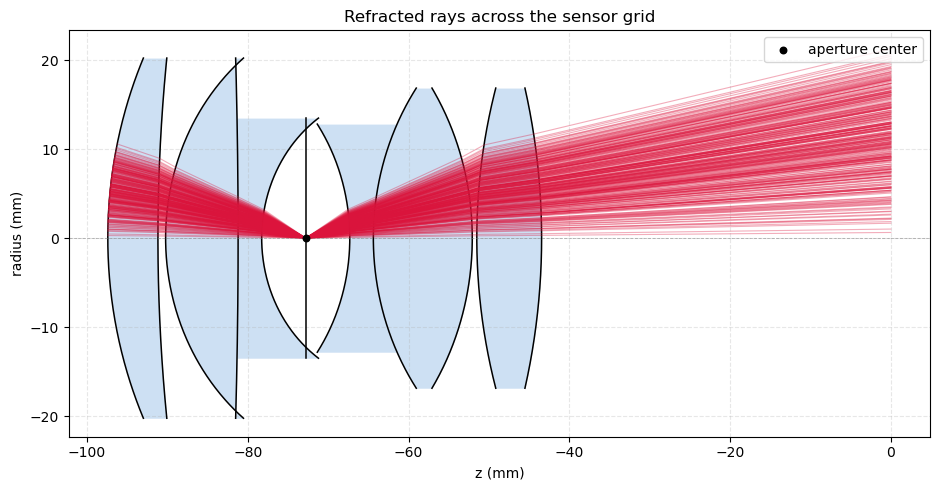

In [27]:
# Plot refracted rays for a pixel grid through the full lens
def plot_grid_rays(width_px=80, height_px=60, *, stride=4, tol_loss=1e-4, tol_step=1e-4, max_iters=24, max_rays=2000):
    pixel_pitch_x = SENSOR_WIDTH_MM / width_px
    pixel_pitch_y = SENSOR_HEIGHT_MM / height_px
    x0 = -0.5 * SENSOR_WIDTH_MM + 0.5 * pixel_pitch_x
    y0 = -0.5 * SENSOR_HEIGHT_MM + 0.5 * pixel_pitch_y
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION_MM
    rays_plotted = 0
    skipped = 0
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    add_lens_profile(ax)
    for j in range(0, height_px, stride):
        y = y0 + j * pixel_pitch_y
        for i in range(0, width_px, stride):
            if rays_plotted >= max_rays:
                break
            x = x0 + i * pixel_pitch_x
            film_pt = np.array([x, y, SENSOR_PLANE_Z_MM], dtype=float)
            sol = find_direction_to_aperture_center(
                film_pt, tol_loss=tol_loss, tol_step=tol_step, max_iters=max_iters
            )
            if sol.get("failure") is not None or sol.get("direction") is None:
                skipped += 1
                continue
            target_far = film_pt + sol["direction"] * travel
            full_trace = trace_ray_verbose_reverse(film_pt, target_far)
            if full_trace.get("failure") is not None:
                skipped += 1
                continue
            path = full_trace["path"]
            r_vals = np.linalg.norm(path[:, :2], axis=1)
            ax.plot(path[:, 2], r_vals, color="crimson", alpha=0.35, linewidth=0.8)
            rays_plotted += 1
        if rays_plotted >= max_rays:
            break
    ax.scatter([APERTURE_Z_MM], [0.0], color="black", s=22, label="aperture center", zorder=5)
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("radius (mm)")
    ax.set_title("Refracted rays across the sensor grid")
    ax.axhline(0.0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    print(f"Plotted {rays_plotted} rays; skipped {skipped} due to failures.")
    return fig, ax
fig_grid, ax_grid = plot_grid_rays()

In [32]:
# Map rays to exit position/direction images (RGBA) at lens outermost surface and into-scene direction
def export_exit_maps(
    width_px=80,
    height_px=60,
    *,
    stride=1,
    tol_loss=1e-5,
    tol_step=1e-5,
    max_iters=10,
    pos_png_path="exit_position.png",
    dir_png_path="exit_direction.png",
    pos_npy_path="exit_position.npy",
    dir_npy_path="exit_direction.npy",
):
    pixel_pitch_x = SENSOR_WIDTH_MM / width_px
    pixel_pitch_y = SENSOR_HEIGHT_MM / height_px
    x0 = -0.5 * SENSOR_WIDTH_MM + 0.5 * pixel_pitch_x
    y0 = -0.5 * SENSOR_HEIGHT_MM + 0.5 * pixel_pitch_y
    travel = abs(LENS_SURFACE_Z[0]) + RAY_EXTENSION_MM
    pos_rgba = np.zeros((height_px, width_px, 4), dtype=np.float32)
    dir_rgba = np.zeros((height_px, width_px, 4), dtype=np.float32)
    # Normalization ranges for positions/directions to map to 0..1
    max_ap_radius = max(seg[3] for seg in LENS)
    pos_range = max(max_ap_radius, 1e-6)
    z_exit = LENS_SURFACE_Z[0]
    z_range = max(abs(z_exit) + 1e-6, 1e-3)
    for j in range(0, height_px, stride):
        y = y0 + j * pixel_pitch_y
        for i in range(0, width_px, stride):
            x = x0 + i * pixel_pitch_x
            film_pt = np.array([x, y, SENSOR_PLANE_Z_MM], dtype=float)
            sol = find_direction_to_aperture_center(
                film_pt, tol_loss=tol_loss, tol_step=tol_step, max_iters=max_iters
            )
            if sol.get("failure") is not None or sol.get("direction") is None:
                pos_rgba[j, i, 3] = 0.0
                dir_rgba[j, i, 3] = 0.0
                continue
            target_far = film_pt + sol["direction"] * travel
            full_trace = trace_ray_verbose_reverse(film_pt, target_far)
            if full_trace.get("failure") is not None:
                pos_rgba[j, i, 3] = 0.0
                dir_rgba[j, i, 3] = 0.0
                continue
            path = full_trace["path"]
            if path.shape[0] < 2:
                pos_rgba[j, i, 3] = 0.0
                dir_rgba[j, i, 3] = 0.0
                continue
            exit_pos = path[1]  # hit on the first (outermost) lens element
            exit_dir = full_trace["result"]["direction"]
            # Normalize to 0..1 for RGB
            pos_rgba[j, i, 0:3] = 0.5 + 0.5 * np.array([exit_pos[0] / pos_range, exit_pos[1] / pos_range, exit_pos[2] / z_range])
            dir_rgba[j, i, 0:3] = 0.5 + 0.5 * np.clip(exit_dir, -1.0, 1.0)
            pos_rgba[j, i, 3] = 1.0
            dir_rgba[j, i, 3] = 1.0
    # Save float data as .npy
    np.save(pos_npy_path, pos_rgba)
    np.save(dir_npy_path, dir_rgba)
    # Also save 8-bit PNGs for quick inspection
    pos_png = (np.clip(pos_rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    dir_png = (np.clip(dir_rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    Image.fromarray(pos_png, mode="RGBA").save(pos_png_path)
    Image.fromarray(dir_png, mode="RGBA").save(dir_png_path)
    print(f"Saved position maps to {pos_png_path} and {pos_npy_path}")
    print(f"Saved direction maps to {dir_png_path} and {dir_npy_path}")
    return pos_rgba, dir_rgba
pos_map, dir_map = export_exit_maps()

Saved position maps to exit_position.png and exit_position.npy
Saved direction maps to exit_direction.png and exit_direction.npy
